## HW02: Exploratory Data Analysis (Part 01)

This is Assignment 02 for the course "Introduction to Data Science" at the Faculty of Information Technology, University of Science, Vietnam National University, Ho Chi Minh City.

---

(Latest update: 26/10/2024)

Student Name: Lý Liên Hoa

Student ID: 22127117

---

## **How to Complete and Submit the Assignment**

&#9889; **Note**: You should follow the instructions below. If anything is unclear, you need to contact the teaching assistant or instructor immediately for timely support.

**How to Do the Assignment**

You will work directly on this notebook file. First, fill in your full name and student ID (MSSV) in the header section of the file above. In the file, complete the tasks in sections marked:
```python
# YOUR CODE HERE
raise NotImplementedError()
```
Or for optional code sections:
```python
# YOUR CODE HERE (OPTION)
```
For markdown cells, complete the answer in the section marked:
```markdown
YOUR ANSWER HERE
```

**How to Submit the Assignment**

Before submitting, select `Kernel` -> `Restart Kernel & Run All Cells` if you are using a local environment, or `Runtime -> Restart session` and run all if using Google Colab, to ensure everything works as expected.

Next, create a submission folder with the following structure:
- Folder named `MSSV` (for example, if your student ID is `1234567`, name the folder `1234567`)
    - File `HW02.ipynb` (no need to submit other files)

Finally, compress this `MSSV` folder in `.zip` format (not `.rar` or any other format) and submit it via the link on Moodle.\
<font color=red>Please make sure to strictly follow this submission guideline.</font>

---

## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

---

## Data collecting

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.). You can download these data from this [link](https://archive.ics.uci.edu/dataset/186/wine+quality).

These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

---

## Exploring your data

### Read raw data from file (0.25 points)

In [2]:
# YOUR CODE HERE
raw_white = pd.read_csv('./data/winequality-white.csv', sep = ';')
raw_red = pd.read_csv('./data/winequality-red.csv', sep = ';')

In [3]:
# TEST 1
raw_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
# TEST 2
raw_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Combine the two dataframes and add a `colors` column to distinguish between red and white wines. Named the dataframe as `raw_df`.

In [5]:
raw_white["colors"] = "white"
raw_red["colors"] = "red"
raw_df = pd.concat([raw_white, raw_red], ignore_index=True)

### How many rows and how many columns does the raw data have? (0.25 points)

Next, you calculate the number of rows and columns of two DataFrames `raw_white` and `raw_red`. Then, store it in the variable `shape_white` and `shape_red`(tuple). 

In [6]:
# YOUR CODE HERE
shape_white = raw_white.shape
shape_red = raw_red.shape
shape = raw_df.shape

In [7]:
# TEST
assert shape_white == (4898, 13)
assert shape_red == (1599, 13)
assert shape == (6497, 13)

### What does each line mean? Does it matter if the lines have different meanings?

YOUR ANSWER HERE

- Each line relates to a specific wine sample with attibutes, such as acidity, sugar level, chloride level, pH, quality rating.

- It matters when the lines have different meanings because it will cause inconsistency across lines which can lead to errors in analysis and wrong results.

### Does the raw data have duplicate rows? (0.25 points)

Next, you calculate the number of rows with duplicate indexes and store it in the variable `red_num_duplicated_rows` and `white_num_duplicated_rows`. In a group of lines with the same index, the first line is not counted as repeated.

In [8]:
# YOUR CODE HERE
white_num_duplicated_rows = raw_white.duplicated().sum()
red_num_duplicated_rows = raw_red.duplicated().sum()

In [9]:
# TEST
assert white_num_duplicated_rows == 937
assert red_num_duplicated_rows == 240

### What does each column mean? (0.25đ)

Read file `winequality.names` and indentify what's type (numerical/ categorical; continous/ discrete; ordinal/ nominal) for each attributes in the dataset.

YOUR ANSWER HERE

| Attibutes           | Type        |
| :------------------ | ----------- |
| fixed acidity       | Continous   |
| volatile acidity    | Continous   |
| citrics acid        | Continous   |
| residual sugar      | Continous   |
| chlorides           | Continous   |
| free sulfur dioxide | Continous   |
| total sulfur dioxide| Continous   |
| density             | Continous   |
| pH                  | Continous   |
| sulphates           | Continous   |
| alcohol             | Continous   |
| quality             | Numerical   |
| color               | Categorical |

### What data type does each column currently have? Are there any columns whose data types are not suitable for further processing? (0.25 points)

Next, you calculate the data type (dtype) of each column in DataFrame `raw_white` and save the result into Series `white_dtypes` (This Series has the index as the column name). Do similar for `raw_red`.

In [10]:
# YOUR CODE HERE
white_dtypes = raw_white.dtypes
red_dtypes = raw_red.dtypes

In [11]:
# TEST 1
white_dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
colors                   object
dtype: object

In [12]:
# TEST 2
red_dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
colors                   object
dtype: object

### For each column with numeric data type, how are the values distributed? (1đ)

For columns with numeric data types, you will calculate:
- Percentage (from 0 to 100) of missing values
- The min
- The lower quartile (phân vị 25)
- The median (phân vị 50)
- The upper quartile (phân vị 75)
- The max

You will save the results to a DataFrame `num_col_info_red` and `num_col_info_white`, where:
- The names of the columns are the names of the numeric columns in `raw_red` and `raw_white`
- Names of rows: "missing_ratio", "min", "lower_quartile", "median", "upper_quartile", "max"  

For ease of viewing, you round all values to 1 decimal place using the `.round(1)` method.

In [13]:
# YOUR CODE HERE
def missing_ratio(series):
    return series.isnull().sum() / len(series) * 100

def lower_quartile(series):
    return series.quantile(0.25)

def median(series):
    return series.median()

def upper_quartile(series):
    return series.quantile(0.75)

numeric_col_red = raw_red.select_dtypes(include=['number'])
num_col_info_red = numeric_col_red 

numeric_col_white = raw_white.select_dtypes(include=['number'])
num_col_info_white = numeric_col_white 

In [14]:
# TEST
num_col_info_red = num_col_info_red.agg([missing_ratio, "min", lower_quartile, median, upper_quartile, "max"])
num_col_info_white = num_col_info_white.agg([missing_ratio, "min", lower_quartile, median, upper_quartile, "max"])

In [15]:
num_col_info_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
missing_ratio,0.0,0.00,0.00,0.0,0.000,0.0,0.0,0.000000,0.00,0.00,0.0,0.0
min,4.6,0.12,0.00,0.9,0.012,1.0,6.0,0.990070,2.74,0.33,8.4,3.0
lower_quartile,7.1,0.39,0.09,1.9,0.070,7.0,22.0,0.995600,3.21,0.55,9.5,5.0
median,7.9,0.52,0.26,2.2,0.079,14.0,38.0,0.996750,3.31,0.62,10.2,6.0
upper_quartile,9.2,0.64,0.42,2.6,0.090,21.0,62.0,0.997835,3.40,0.73,11.1,6.0
max,15.9,1.58,1.00,15.5,0.611,72.0,289.0,1.003690,4.01,2.00,14.9,8.0


### For each column with a non-numeric data type, how are the values distributed?(1đ)

For columns with non-numeric data types, you calculate:
- Percentage (from 0 to 100) of missing values
- Number of values (the values here are different values and we do not consider missing values): with columns whose type is categorical, it is a set with a finite number of categories. Directly counting the number of values in these columns doesn't make much sense, so it's better to count the number of elements of all types.
- The percentage (from 0 to 100) of each value is sorted by decreasing percentage (we do not consider missing values, the ratio is the ratio compared to the number of non-missing values): you use a dictionary to store , key is the value, value is the percentage; With the column corresponding to each type, the method is similar to above.

You will save the results to DataFrame `cat_col_info_df`, where:
- The names of the columns are the names of the non-numeric columns in `raw_df`
- The names of the lines are: "missing_ratio", "num_values", "value_ratios"

For ease of viewing, you round all values to 1 decimal place using the `.round(1)` method.

In [16]:
# YOUR CODE HERE
def missing_ratio(column):
    return column.isnull().sum() / len(column) * 100

def num_values(column):
    return column.nunique()

def value_ratios(column):
    value_counts = column.value_counts(normalize=True) * 100
    ratio = value_counts.sort_values(ascending=False).round(1).to_dict()
    return ratio

cat_col_info_df = raw_df.select_dtypes(exclude=['number'])

In [17]:
# TEST
cat_col_info_df = cat_col_info_df.agg([missing_ratio, num_values, value_ratios])
cat_col_info_df

,colors
missing_ratio,0.0
num_values,2
value_ratios,"{'white': 75.4, 'red': 24.6}"


## Exploring your data (Cont)

### Task 01: Analyzing wine quality via histogram.

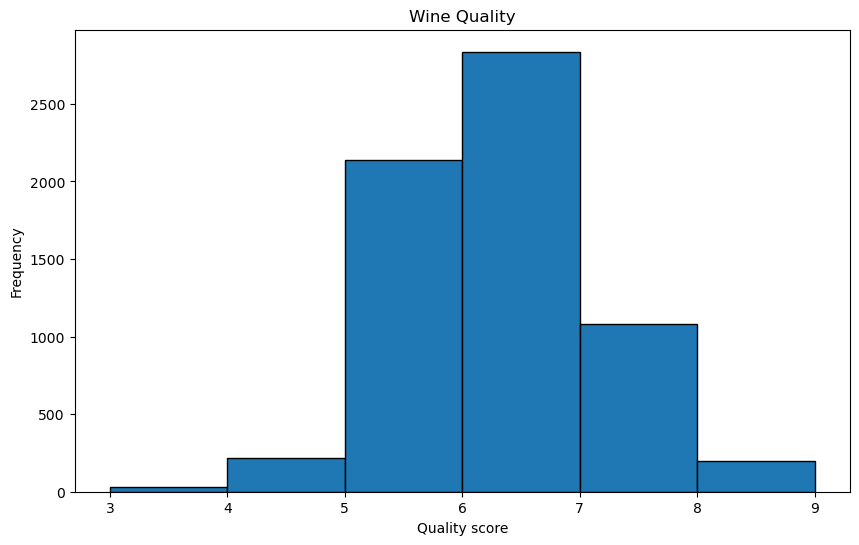

In [18]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.hist(raw_df['quality'], bins=range(3, 10), label='Wine', edgecolor='black')

plt.title('Wine Quality')
plt.xlabel('Quality score')
plt.ylabel('Frequency')

plt.xticks(range(3, 10))

plt.show()

### Task 02: Aanalyzing acidity in red and white wine.

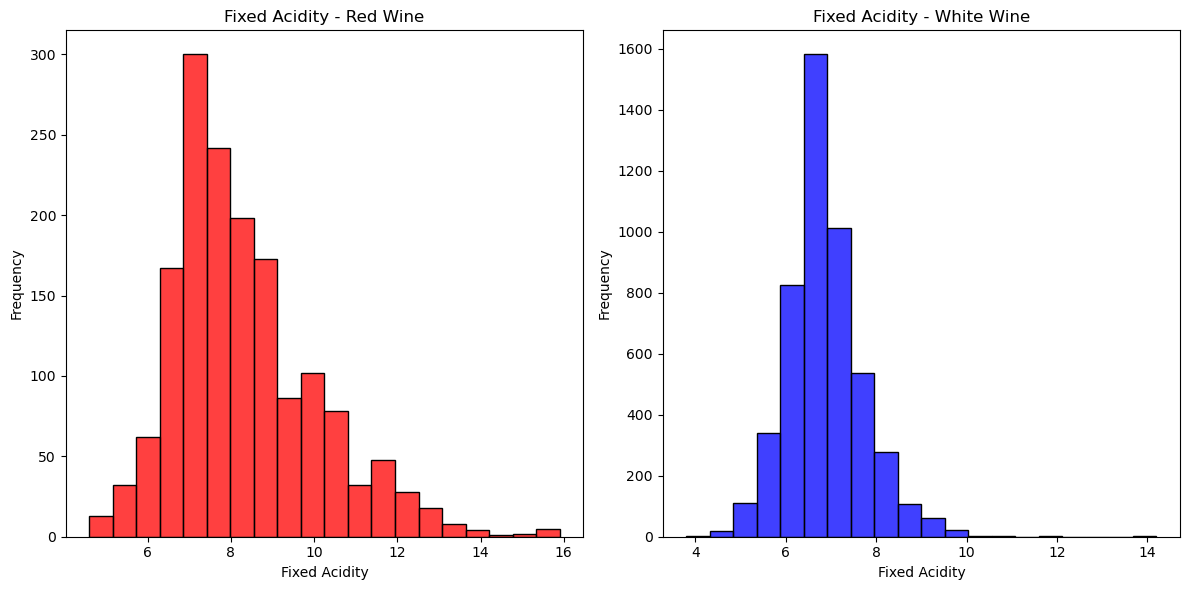

In [19]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(raw_red["fixed acidity"], bins=20, kde=False, color="red")
plt.title("Fixed Acidity - Red Wine")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(raw_white["fixed acidity"], bins=20, kde=False, color="blue")
plt.title("Fixed Acidity - White Wine")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

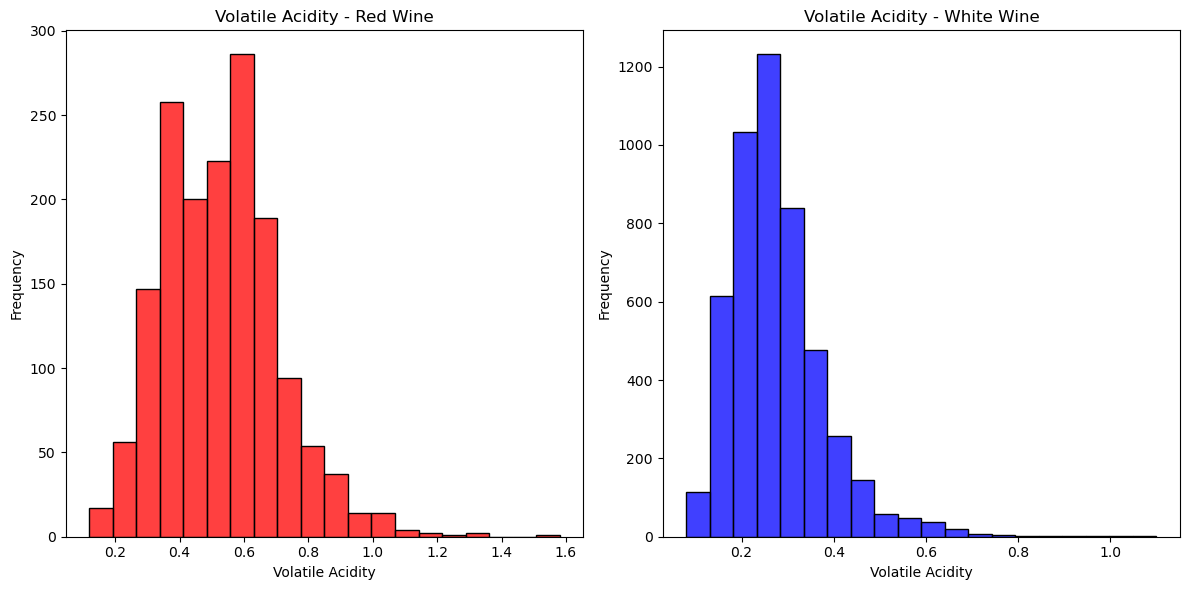

In [20]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(raw_red["volatile acidity"], bins=20, kde=False, color="red")
plt.title("Volatile Acidity - Red Wine")
plt.xlabel("Volatile Acidity")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(raw_white["volatile acidity"], bins=20, kde=False, color="blue")
plt.title("Volatile Acidity - White Wine")
plt.xlabel("Volatile Acidity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

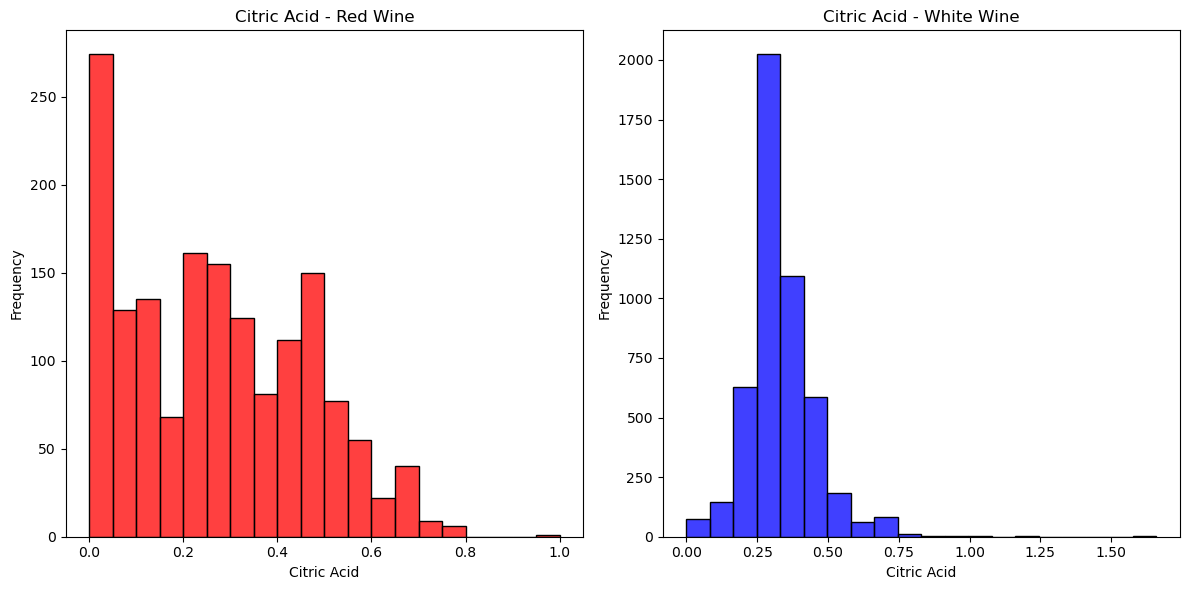

In [21]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(raw_red["citric acid"], bins=20, kde=False, color="red")
plt.title("Citric Acid - Red Wine")
plt.xlabel("Citric Acid")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(raw_white["citric acid"], bins=20, kde=False, color="blue")
plt.title("Citric Acid - White Wine")
plt.xlabel("Citric Acid")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Task 03: Analyzing sulfur dioxide for each type of wines. Try to focus on the ratio of free and total sulfur.

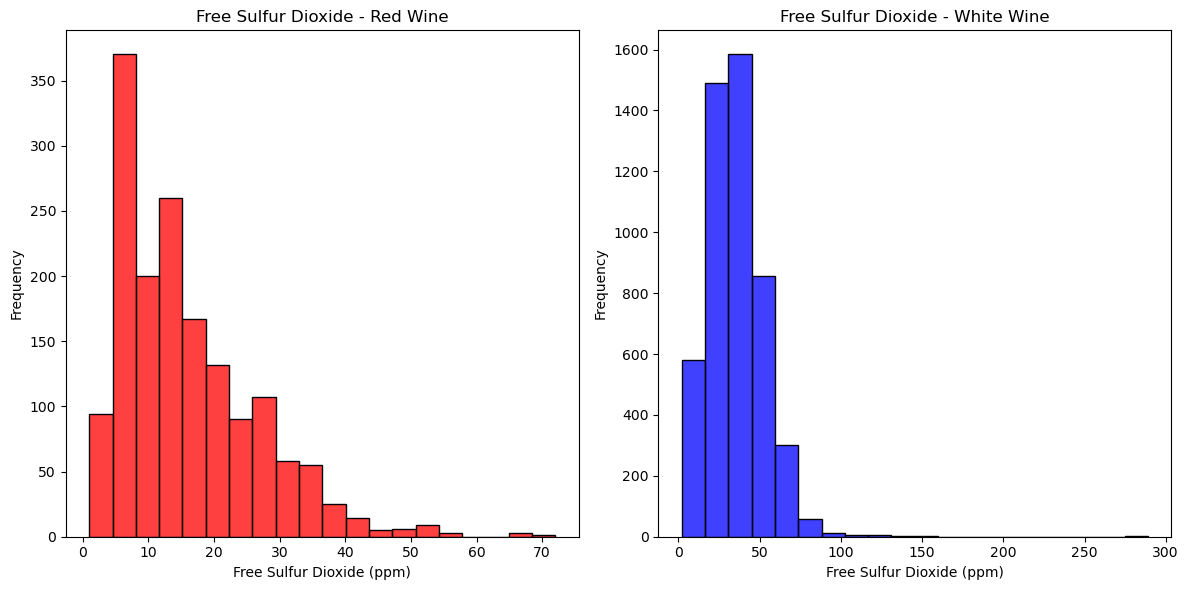

In [22]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(raw_red["free sulfur dioxide"], bins=20, kde=False, color="red")
plt.title("Free Sulfur Dioxide - Red Wine")
plt.xlabel("Free Sulfur Dioxide (ppm)")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(raw_white["free sulfur dioxide"], bins=20, kde=False, color="blue")
plt.title("Free Sulfur Dioxide - White Wine")
plt.xlabel("Free Sulfur Dioxide (ppm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

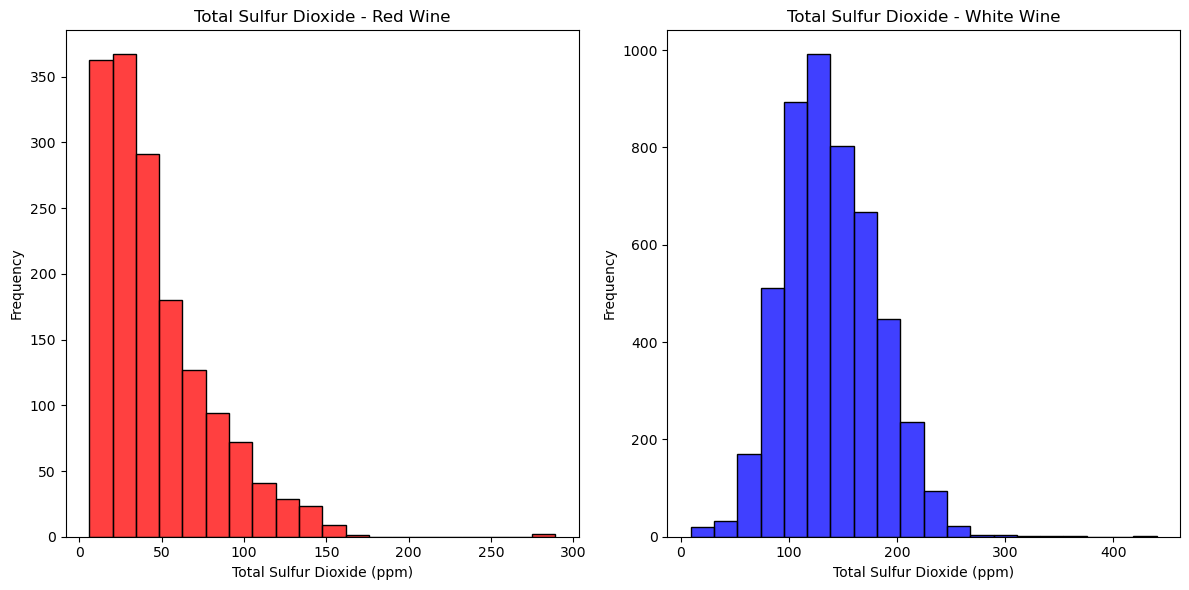

In [23]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(raw_red["total sulfur dioxide"], bins=20, kde=False, color="red")
plt.title("Total Sulfur Dioxide - Red Wine")
plt.xlabel("Total Sulfur Dioxide (ppm)")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(raw_white["total sulfur dioxide"], bins=20, kde=False, color="blue")
plt.title("Total Sulfur Dioxide - White Wine")
plt.xlabel("Total Sulfur Dioxide (ppm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

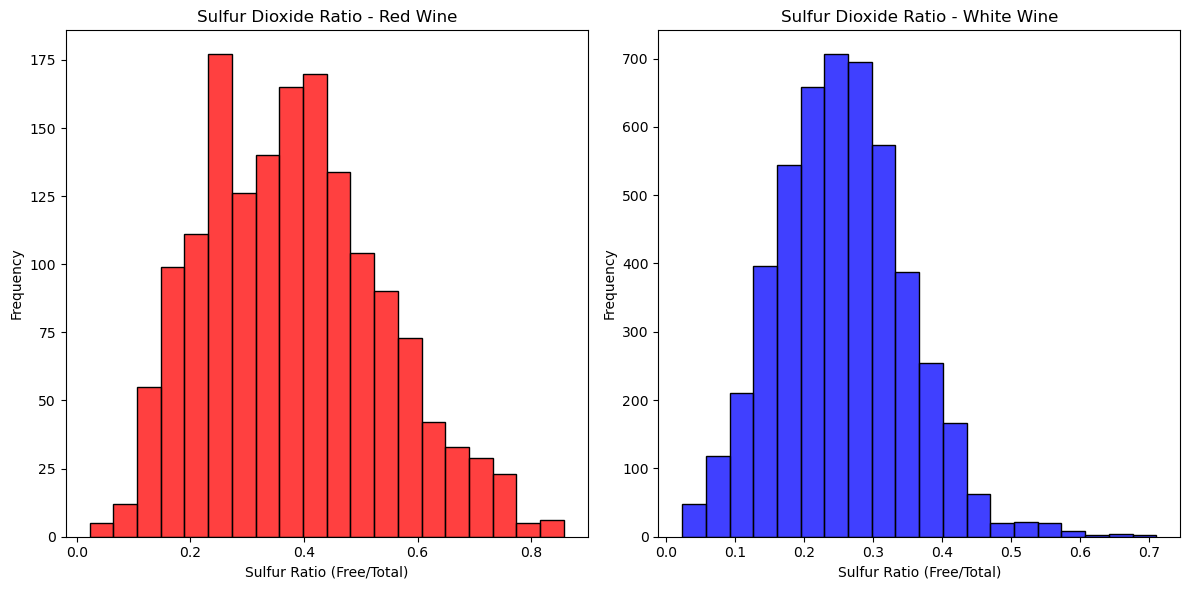

In [24]:
# YOUR CODE HERE
sulfur_dioxide_red = raw_red['free sulfur dioxide'] / raw_red['total sulfur dioxide']
sulfur_dioxide_white = raw_white['free sulfur dioxide'] / raw_white['total sulfur dioxide']


plt.figure(figsize=(12, 6))

# Red wine
plt.subplot(1, 2, 1)
sns.histplot(sulfur_dioxide_red, bins=20, kde=False, color="red")
plt.title("Sulfur Dioxide Ratio - Red Wine")
plt.xlabel("Sulfur Ratio (Free/Total)")
plt.ylabel("Frequency")

# White wine
plt.subplot(1, 2, 2)
sns.histplot(sulfur_dioxide_white, bins=20, kde=False, color="blue")
plt.title("Sulfur Dioxide Ratio - White Wine")
plt.xlabel("Sulfur Ratio (Free/Total)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Task 04: What about the residual sugar? How does it affect wine quality?

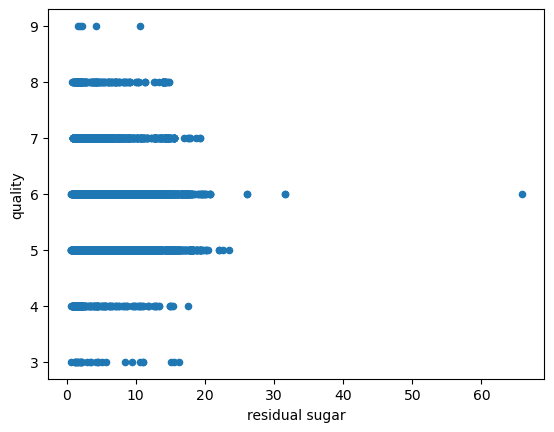

In [25]:
# YOUR CODE HERE
raw_df.plot(y='quality', x='residual sugar', kind='scatter');

Residual sugar has a small effect on wine quality as we can see when wine quality increases, the amount of residual sugar does not show a clear upward or downward trend.

### Task 05: Alcohol plays a vital role in wine production. How does it affect wine quality?

<AxesSubplot:xlabel='alcohol', ylabel='quality'>

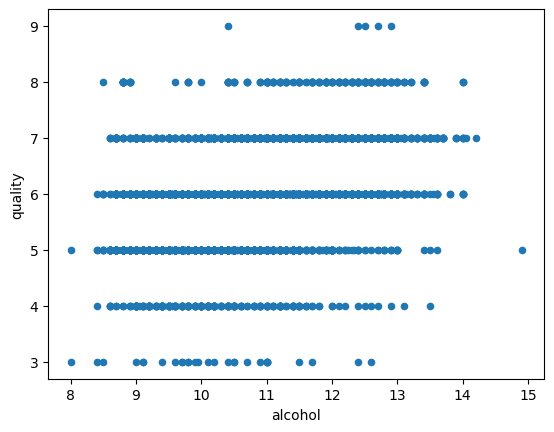

In [26]:
# YOUR CODE HERE
raw_df.plot(y='quality', x='alcohol', kind='scatter')

In this chart, it can be observed that the higher alcohol amount the higher wine's quality. As a result, we can say that alcohol amount plays a vital role in wine quality.

### Task 06: For each type of wine, how is density distributed? Is it importance to wine quality?

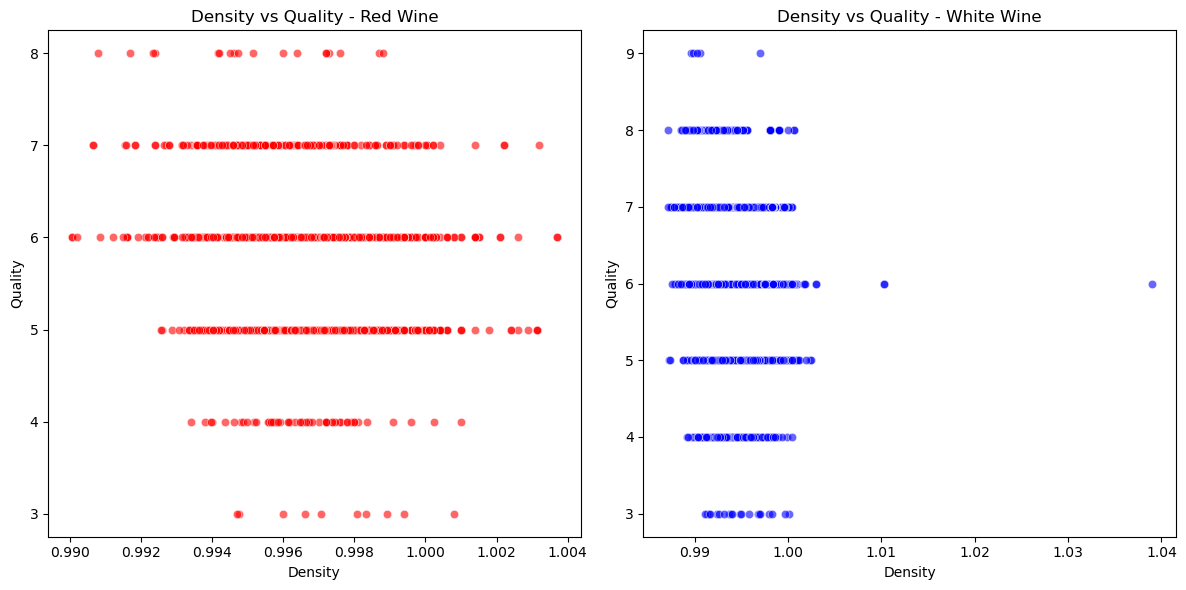

In [27]:
# YOUR CODE HERE
# Scatter plot for density vs quality
plt.figure(figsize=(12, 6))

# Red Wine
plt.subplot(1, 2, 1)
sns.scatterplot(data=raw_red, x="density", y="quality", color="red", alpha=0.6)
plt.title("Density vs Quality - Red Wine")
plt.xlabel("Density")
plt.ylabel("Quality")

# White Wine
plt.subplot(1, 2, 2)
sns.scatterplot(data=raw_white, x="density", y="quality", color="blue", alpha=0.6)
plt.title("Density vs Quality - White Wine")
plt.xlabel("Density")
plt.ylabel("Quality")

plt.tight_layout()
plt.show()


- Density for both red and white wines is concentrated around 0.99 to 1.003
- From the graph, it seems that when the alcohol density is lower, the quality of the wine will be higher.

### Task 07: How are Chloride characteristics distributed in these two types of wines? 

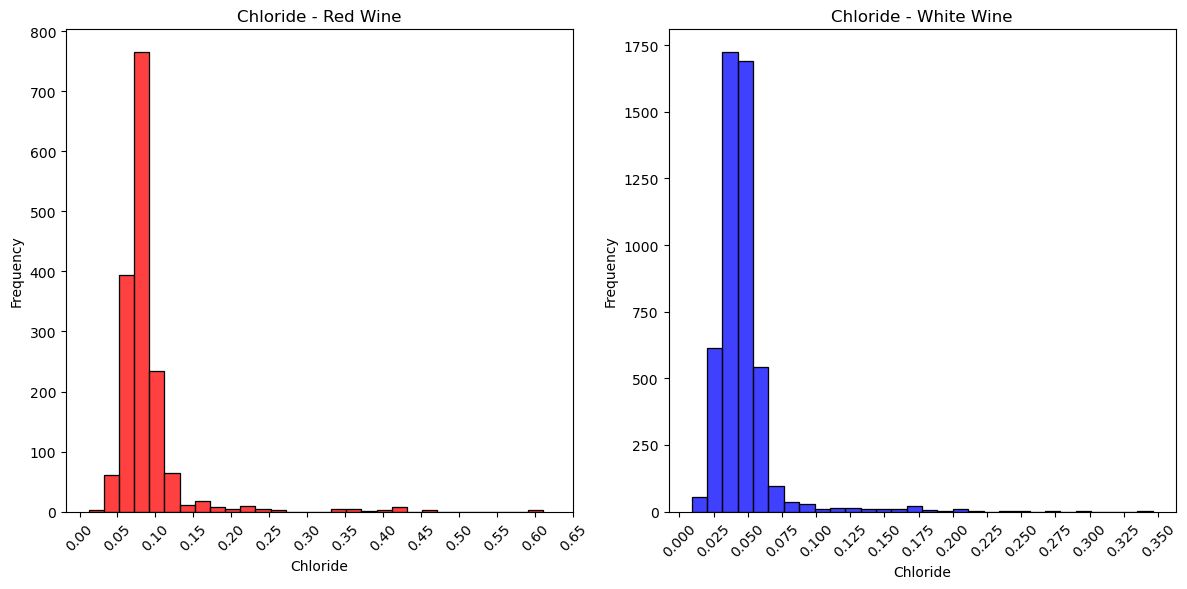

In [28]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Red wine
red_bins = np.arange(0, raw_red["chlorides"].max() + 0.05, 0.05)

plt.subplot(1, 2, 1)
sns.histplot(raw_red["chlorides"], bins=30, kde=False, color="red")
plt.title("Chloride - Red Wine")
plt.xlabel("Chloride")
plt.ylabel("Frequency")

plt.xticks(red_bins, rotation=45)

# White wine
white_bins = np.arange(0, raw_white["chlorides"].max() + 0.025, 0.025)

plt.subplot(1, 2, 2)
sns.histplot(raw_white["chlorides"], bins=30, kde=False, color="blue")
plt.title("Chloride - White Wine")
plt.xlabel("Chloride")
plt.ylabel("Frequency")

plt.xticks(white_bins, rotation=45)

plt.tight_layout()
plt.show()

- The chloride distribution of red wine is mainly in the range of 0.05-0.1. 
- As for white wine, the chloride content is mainly in the range of 0.025 to about 0.07. 
- The chloride content of white wine has a lower chloride range with a maximum of about 0.35, while hat of red wine is about 0.6

## Analyze the correlation between two or more variables

### Task 08: Correlation matrix analysis

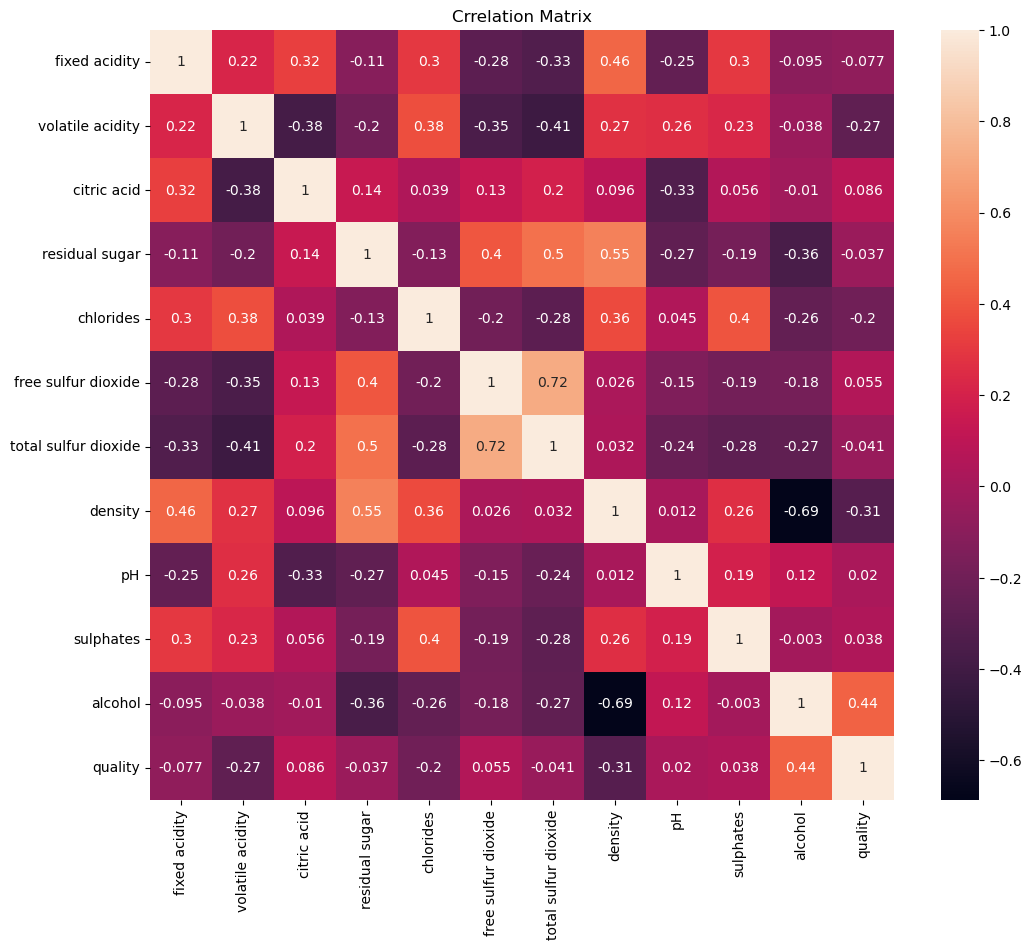

In [29]:
# YOUR CODE HERE
correlation_matrix = raw_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Crrelation Matrix")

plt.show()

### Analysis of the influence of variables on wine quality

#### Task 09: Investigating the relationship between `Density` and `Quality`

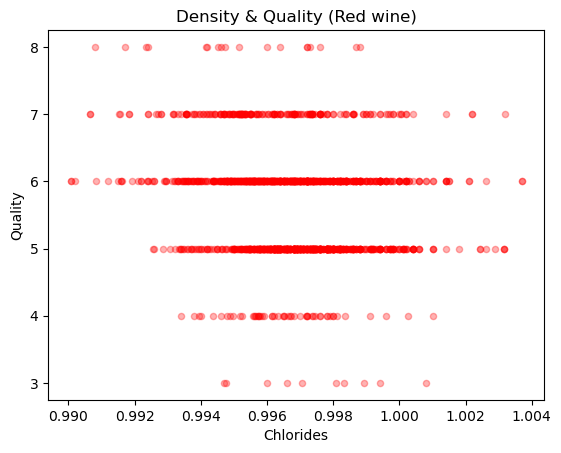

In [30]:
# YOUR CODE HERE
raw_red.plot(y='quality', x='density', kind='scatter', color='red', alpha=0.3)

plt.title("Density & Quality (Red wine)")
plt.xlabel("Chlorides")
plt.ylabel("Quality")

plt.show()

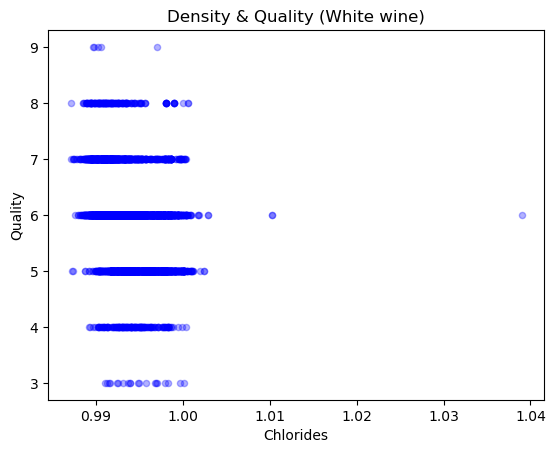

In [31]:
# YOUR CODE HERE
raw_white.plot(y='quality', x='density', kind='scatter', color='blue', alpha=0.3)


plt.title("Density & Quality (White wine)")
plt.xlabel("Chlorides")
plt.ylabel("Quality")

plt.show()

#### Task 10: Investigating the relationship between `Alcohol` and `Quality`

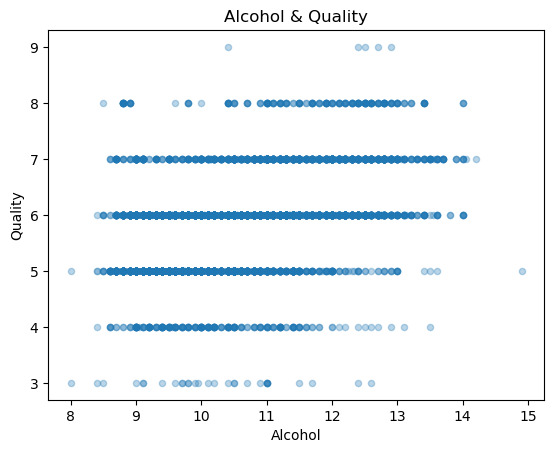

In [32]:
# YOUR CODE HERE
raw_df.plot(y='quality', x='alcohol', kind='scatter', alpha=0.3);

plt.title("Alcohol & Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.show()

#### Task 11: Investigating the relationship between `Chlorides` and `Quality`

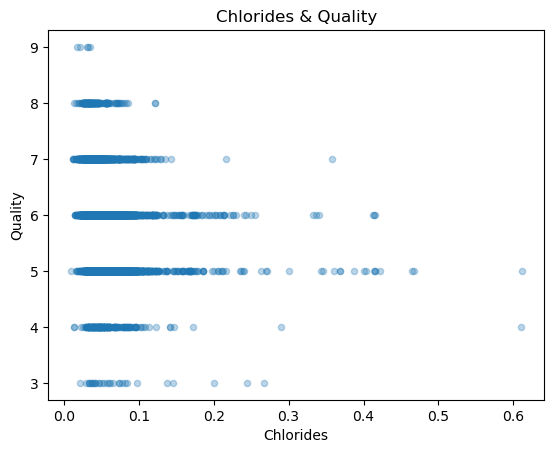

In [33]:
# YOUR CODE HERE
raw_df.plot(y='quality', x='chlorides', kind='scatter', alpha=0.3)

plt.title("Chlorides & Quality")
plt.xlabel("Chlorides")
plt.ylabel("Quality")

plt.show()

#### Task 12: Investigating the relationship between `Volatile Acidity` and `Quality`

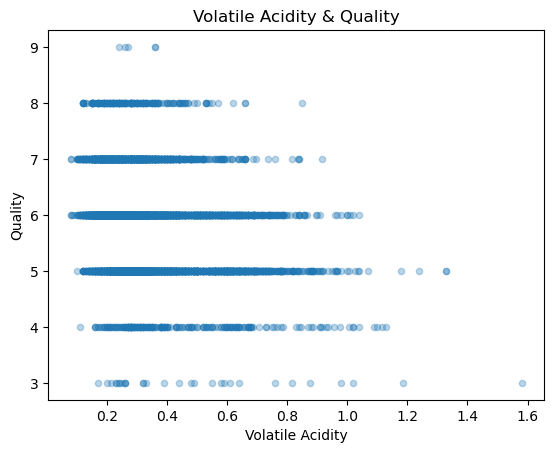

In [34]:
# YOUR CODE HERE
raw_df.plot(y='quality', x='volatile acidity', kind='scatter', alpha=0.3)

plt.title("Volatile Acidity & Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")

plt.show()

#### Task 13: Investigation of the relationship between total SO2 and residual sugar after fermentation

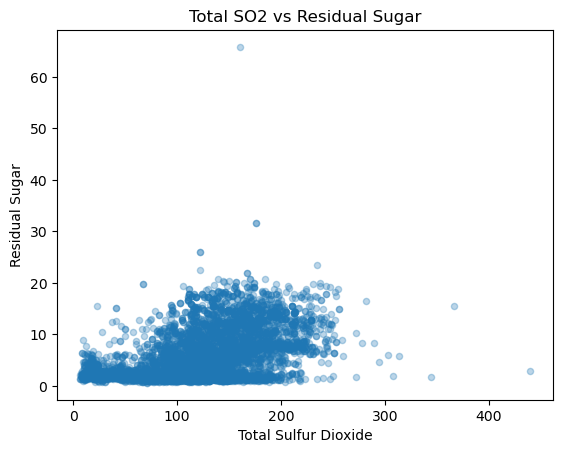

In [35]:
# YOUR CODE HERE
raw_df.plot(x='total sulfur dioxide', y='residual sugar', kind='scatter', alpha=0.3)

plt.title("Total SO2 vs Residual Sugar")
plt.xlabel("Total Sulfur Dioxide")
plt.ylabel("Residual Sugar")

plt.show()

#### Task 14: Investigation of the impact of alcohol concentration and sugar content on alcohol density

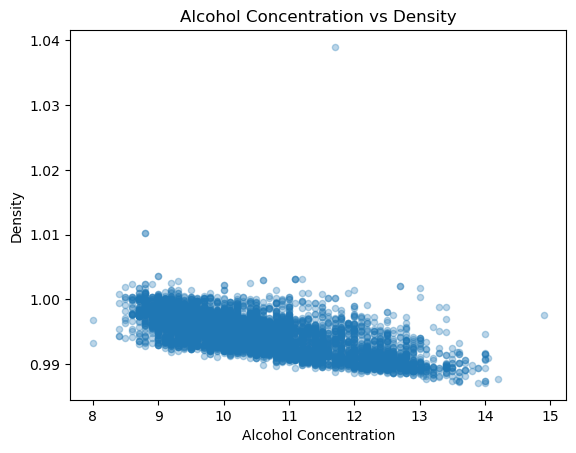

In [36]:
# YOUR CODE HERE
raw_df.plot(x='alcohol', y='density', kind='scatter', alpha=0.3)
plt.title('Alcohol Concentration vs Density')
plt.xlabel('Alcohol Concentration')
plt.ylabel('Density')

plt.show()

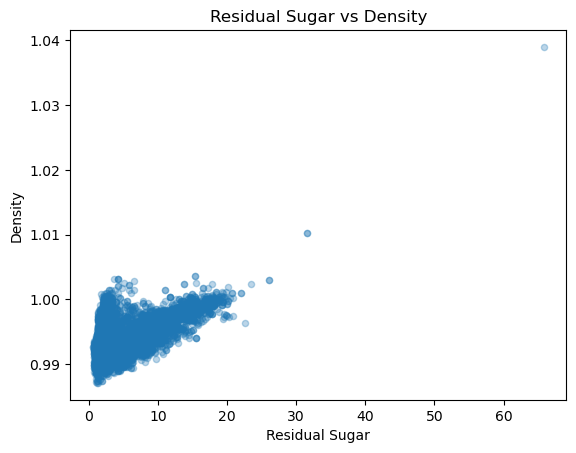

In [37]:
# YOUR CODE HERE
raw_df.plot(x='residual sugar', y='density', kind='scatter', alpha=0.3)
plt.title('Residual Sugar vs Density')
plt.xlabel('Residual Sugar')
plt.ylabel('Density')

plt.show()

### Analysis based on wine color

#### Task 15: Analyze the relationship between color and density of wine

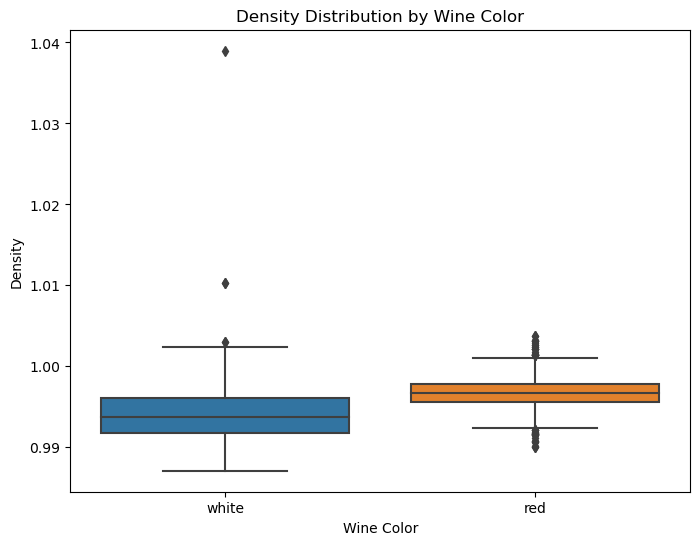

In [38]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="colors", y="density")
plt.title("Density Distribution by Wine Color")
plt.xlabel("Wine Color")
plt.ylabel("Density")
plt.show()

#### Task 16: Analyze the relationship between color and residual sugar after fermentation

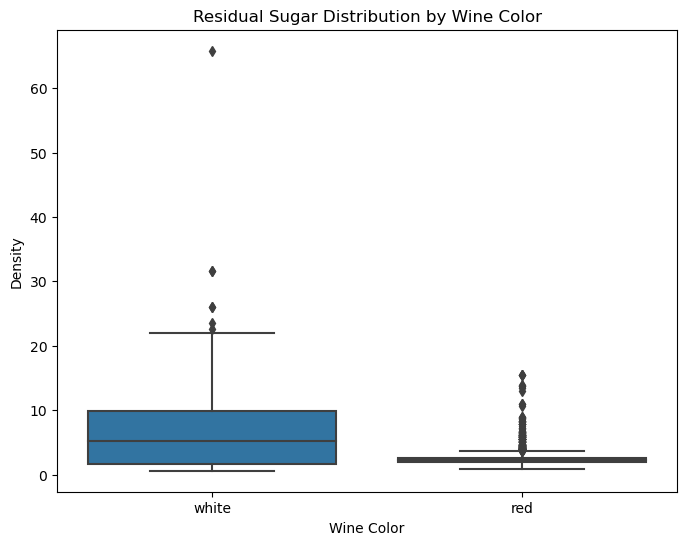

In [39]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="colors", y="residual sugar")
plt.title("Residual Sugar Distribution by Wine Color")
plt.xlabel("Wine Color")
plt.ylabel("Density")
plt.show()

#### Task 17: Analyze the relationship between color and total sulfur content in wine

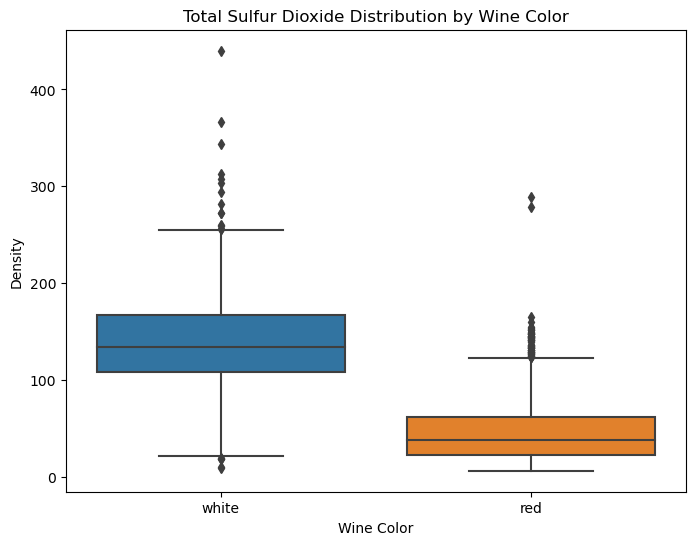

In [40]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="colors", y="total sulfur dioxide")
plt.title("Total Sulfur Dioxide Distribution by Wine Color")
plt.xlabel("Wine Color")
plt.ylabel("Density")
plt.show()

#### Task 18: Analyze the relationship between color and free sulfur content in wine

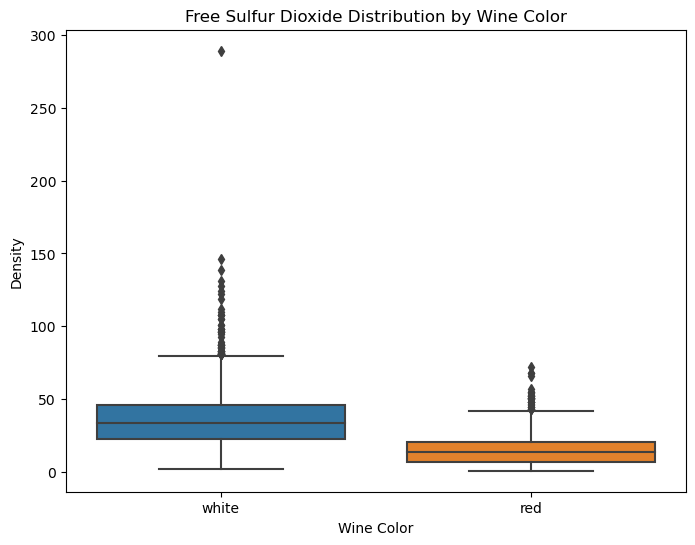

In [41]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="colors", y="free sulfur dioxide")
plt.title("Free Sulfur Dioxide Distribution by Wine Color")
plt.xlabel("Wine Color")
plt.ylabel("Density")
plt.show()

#### Task 19: Analyze the relationship between color and acidity of wine

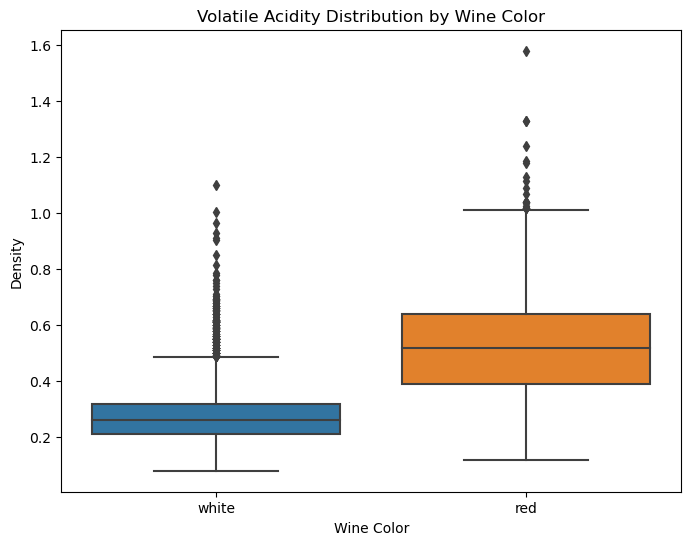

In [42]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="colors", y="volatile acidity")
plt.title("Volatile Acidity Distribution by Wine Color")
plt.xlabel("Wine Color")
plt.ylabel("Density")
plt.show()

### Correlation analysis between variables based on color

#### Task 20: Investigate the correlation between density and wine quality based on color

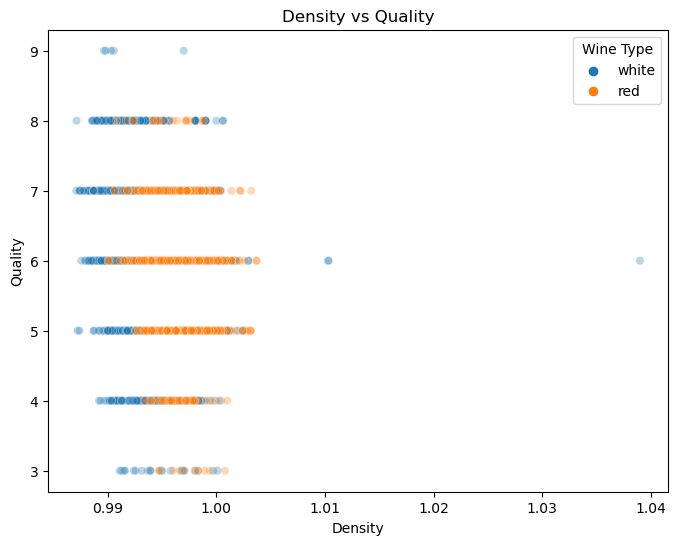

In [43]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))

sns.scatterplot(data=raw_df, x="density", y="quality", hue="colors", alpha=0.3)

plt.title("Density vs Quality")
plt.xlabel("Density")
plt.ylabel("Quality")
plt.legend(title="Wine Type")

plt.show()

#### Task 21: Investigate the correlation between alcohol concentration and wine quality based on color

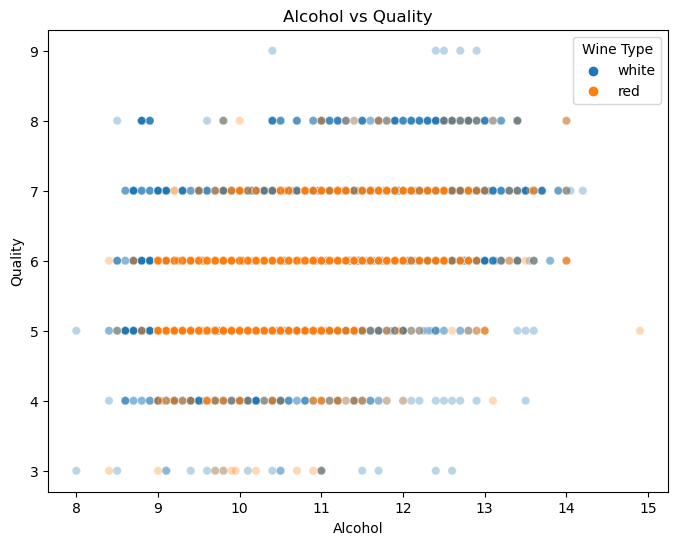

In [44]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))

sns.scatterplot(data=raw_df, x="alcohol", y="quality", hue="colors", alpha=0.3)

plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.legend(title="Wine Type")

plt.show()

#### Task 22: Investigate the correlation between salt content and wine quality based on color

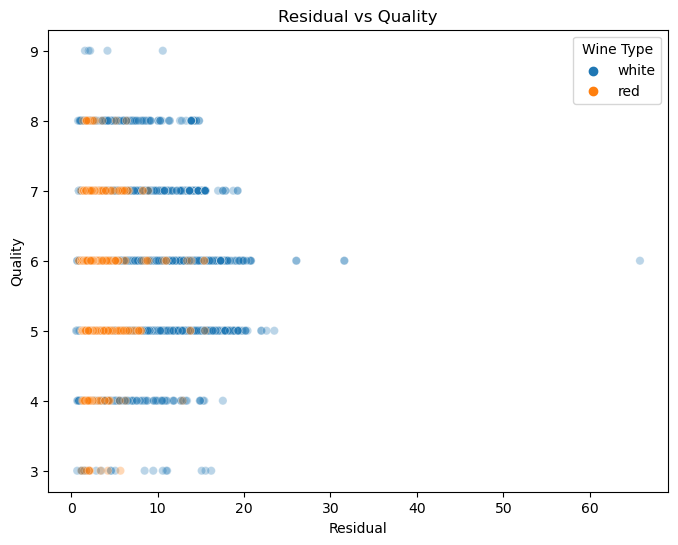

In [45]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))

sns.scatterplot(data=raw_df, x="residual sugar", y="quality", hue="colors", alpha=0.3)

plt.title("Residual vs Quality")
plt.xlabel("Residual")
plt.ylabel("Quality")
plt.legend(title="Wine Type")

plt.show()

#### Task 23: Investigate the correlation between acidity and wine quality based on color

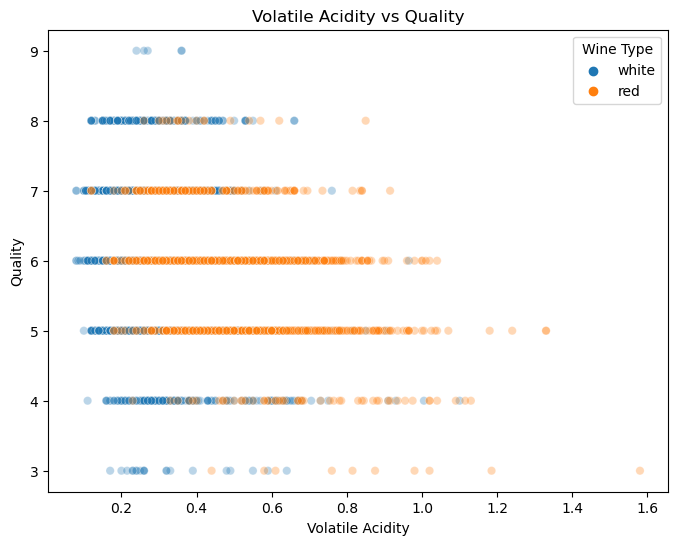

In [46]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))

sns.scatterplot(data=raw_df, x="volatile acidity", y="quality", hue="colors", alpha=0.3)

plt.title("Volatile Acidity vs Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.legend(title="Wine Type")

plt.show()

### Multi-attributes analysis

#### Task 24: Chlorides and Sulphates on wine quality

In [47]:
# YOUR CODE HERE
correlation_chlorides_quality = raw_df["chlorides"].corr(raw_df["quality"])
correlation_sulphates_quality = raw_df["sulphates"].corr(raw_df["quality"])

print(f"Correlation between Chlorides and Quality: {correlation_chlorides_quality:.2f}")
print(f"Correlation between Sulphates and Quality: {correlation_sulphates_quality:.2f}")

Correlation between Chlorides and Quality: -0.20
Correlation between Sulphates and Quality: 0.04


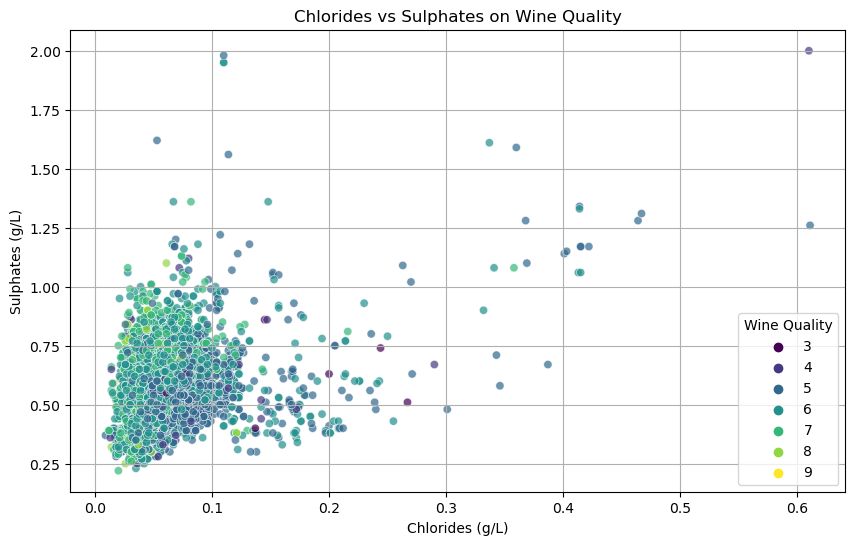

In [48]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=raw_df, x="chlorides", y="sulphates", hue="quality", palette="viridis", alpha=0.7)

plt.title("Chlorides vs Sulphates on Wine Quality")
plt.xlabel("Chlorides (g/L)")
plt.ylabel("Sulphates (g/L)")
plt.legend(title="Wine Quality")

plt.grid(True)
plt.show()

#### Task 25: Sulfur Dioxide Ratio and Volatile Acidity Ratio on wine quality

In [49]:
# YOUR CODE HERE
raw_df["so2_ratio"] = raw_df["free sulfur dioxide"] / raw_df["total sulfur dioxide"]

correlation_so2_quality = raw_df["so2_ratio"].corr(raw_df["quality"])
correlation_vol_acidity_quality = raw_df["volatile acidity"].corr(raw_df["quality"])

print(f"Correlation between SO2 Ratio and Quality: {correlation_so2_quality:.2f}")
print(f"Correlation between Volatile Acidity and Quality: {correlation_vol_acidity_quality:.2f}")

Correlation between SO2 Ratio and Quality: 0.12
Correlation between Volatile Acidity and Quality: -0.27


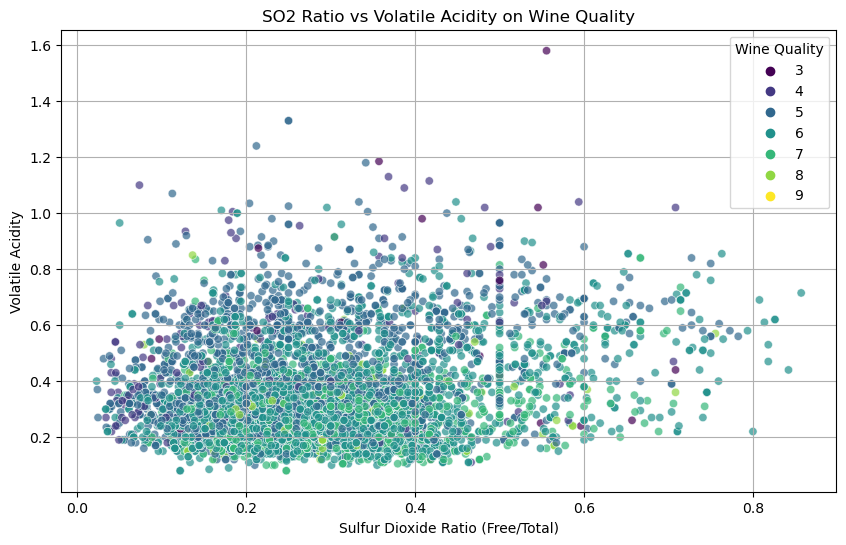

In [50]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=raw_df, x="so2_ratio", y="volatile acidity", hue="quality", palette="viridis", alpha=0.7)

plt.title("SO2 Ratio vs Volatile Acidity on Wine Quality")
plt.xlabel("Sulfur Dioxide Ratio (Free/Total)")
plt.ylabel("Volatile Acidity")
plt.legend(title="Wine Quality")

plt.grid(True)
plt.show()

#### Task 26: Volatile Acidity and Alcohol on wine quality

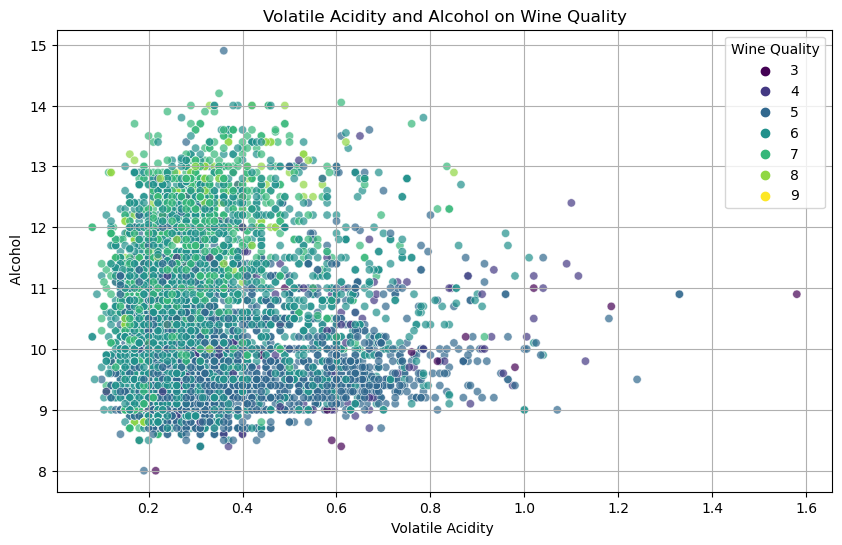

In [51]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=raw_df, x="volatile acidity", y="alcohol", hue="quality", palette="viridis", alpha=0.7)

plt.title("Volatile Acidity and Alcohol on Wine Quality")
plt.xlabel("Volatile Acidity ")
plt.ylabel(" Alcohol")
plt.legend(title="Wine Quality")

plt.grid(True)
plt.show()

### Main Factors Influencing Wine Quality

Based on the above analysis, you should decide what factors affect wine quality.

In [52]:
# YOUR CODE HERE
print("Main Factors Influencing Wine Quality: Acidity, Density, Alcohol, and Chlorides")

Main Factors Influencing Wine Quality: Acidity, Density, Alcohol, and Chlorides
